# 0. python実行環境の解析

In [3]:
import sys
import os

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("sys.path[0]:", sys.path[0])
print("Current working directory:", os.getcwd())


Python executable: /home/hashikami/projects/Diff/.venv/bin/python
Python version: 3.8.10 (default, Mar 13 2023, 10:26:41) 
[GCC 9.4.0]
sys.path[0]: /home/hashikami/projects/Diff
Current working directory: /home/hashikami/projects/Diff/notebooks


In [4]:
import os

def is_anaconda_active():
    conda_prefix = os.environ.get('CONDA_PREFIX', None)
    conda_default_env = os.environ.get('CONDA_DEFAULT_ENV', None)
    if conda_prefix or conda_default_env:
        print("Anaconda環境がアクチベートされています。")
        print(f"CONDA_PREFIX: {conda_prefix}")
        print(f"CONDA_DEFAULT_ENV: {conda_default_env}")
        return True
    else:
        print("Anaconda環境はアクチベートされていません。")
        return False

is_anaconda_active()


Anaconda環境はアクチベートされていません。


False

In [5]:
import os

os.environ['PYTHONPATH']

'/home/hashikami/projects/Diff'

# 1. 条件値のスケールをmini-max正規化により変換した結果を保存

## 1.1 条件値のmin-max値を保存

In [11]:
from dataset.morphomnist import load_morphomnist_like


root_dir = "/home/hashikami/datadrive/MorphoMNIST"
images, labels, metrics = load_morphomnist_like(root_dir, train = True, columns=['intensity', 'thickness'])

In [23]:
# 条件情報の最大値、最小値をそれぞれ保存

import json

cond_stats = {
    "thickness": {"min": metrics['thickness'].min(), "max": metrics['thickness'].max()},
    "intensity": {"min": metrics['intensity'].min(), "max": metrics['intensity'].max()}
}

with open("dataset/cond_stats.json", "w") as f:
    json.dump(cond_stats, f, indent=2)

## 1.2 min-max scale関数の動作テスト

In [31]:
import torch
from diffusion.utils.preprocess import scale_conditions


with open("dataset/cond_stats.json", "r") as f:
    cond_stats = json.load(f)

metrics_tensor = torch.tensor(metrics.values, dtype=torch.float32)
metrics_names = ['thickness', 'intensity']

scaled_metrics = scale_conditions(metrics_tensor, metrics_names, cond_stats)

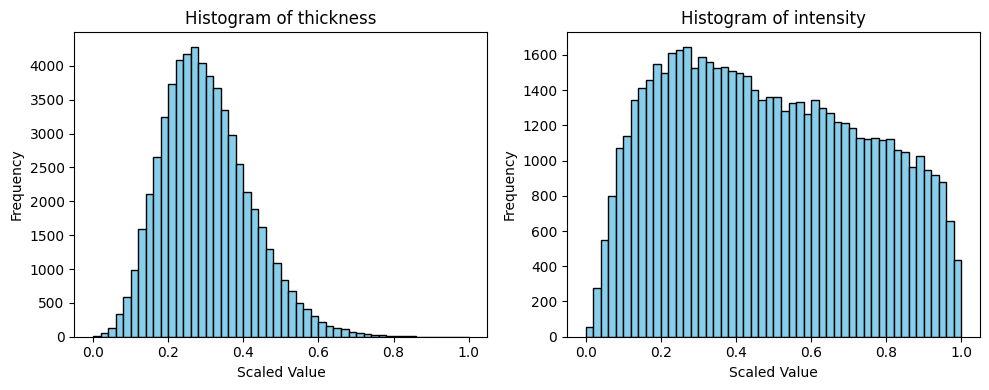

In [33]:
import pandas as pd
import matplotlib.pyplot as plt


scaled_metrics_df = pd.DataFrame(scaled_metrics.numpy(), columns=metrics_names)

fig, axes = plt.subplots(1, len(metrics_names), figsize=(10, 4))
for i, col in enumerate(metrics_names):
    axes[i].hist(scaled_metrics_df[col], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()



# 2. 拡散モデルを用いた反事実的画像編集

In [2]:
import os

os.chdir('/home/hashikami/projects/Diff')

In [4]:
# metricsのサンプルを取得

import torch
import matplotlib.pyplot as plt
import json
from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike
#from diffusion.utils.utils import load_json
from diffusion.utils.preprocess import scale_conditions
from diffusion.utils.utils import load_json, resize_images

# Example usage
batch_size = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/MorphoMNIST",
                            columns=['intensity', 'thickness'], train=False)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
intensity = next(iter(data_loader))['intensity'][:, None].float()
thickness = next(iter(data_loader))['thickness'][:, None].float()
metrics = torch.cat([intensity, thickness], dim=1).to(device)

# metricsのスケールを0-1に変換
cond_stats_path = "/home/hashikami/projects/Diff/dataset/cond_stats.json"
cond_stats = load_json(cond_stats_path)
scaled_metrics = scale_conditions(metrics, ['intensity', 'thickness'], cond_stats)
images = next(iter(data_loader))['image'].unsqueeze(1) / 255.0 # 値のスケールに注意せよ
images = resize_images(images, (32, 32)).squeeze(1)

/home/hashikami/projects/Diff/dataset/morphomnist.py:90: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:199.)
  self.images = torch.as_tensor(images)


## 1.1 条件付き生成

### 2025-07-17_14チェックポイント

In [48]:
# checkpointの読み込み

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import itertools
from tqdm.auto import tqdm

from diffusion.utils.utils import load_json
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint
import json


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-17_13/config_20250717.json"
config = load_json(file_path)
epochs = config['epochs']
timesteps = config['timesteps']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename='/home/hashikami/checkpoint/checkpoint_2025-07-17_14.pth')

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 53.25it/s]


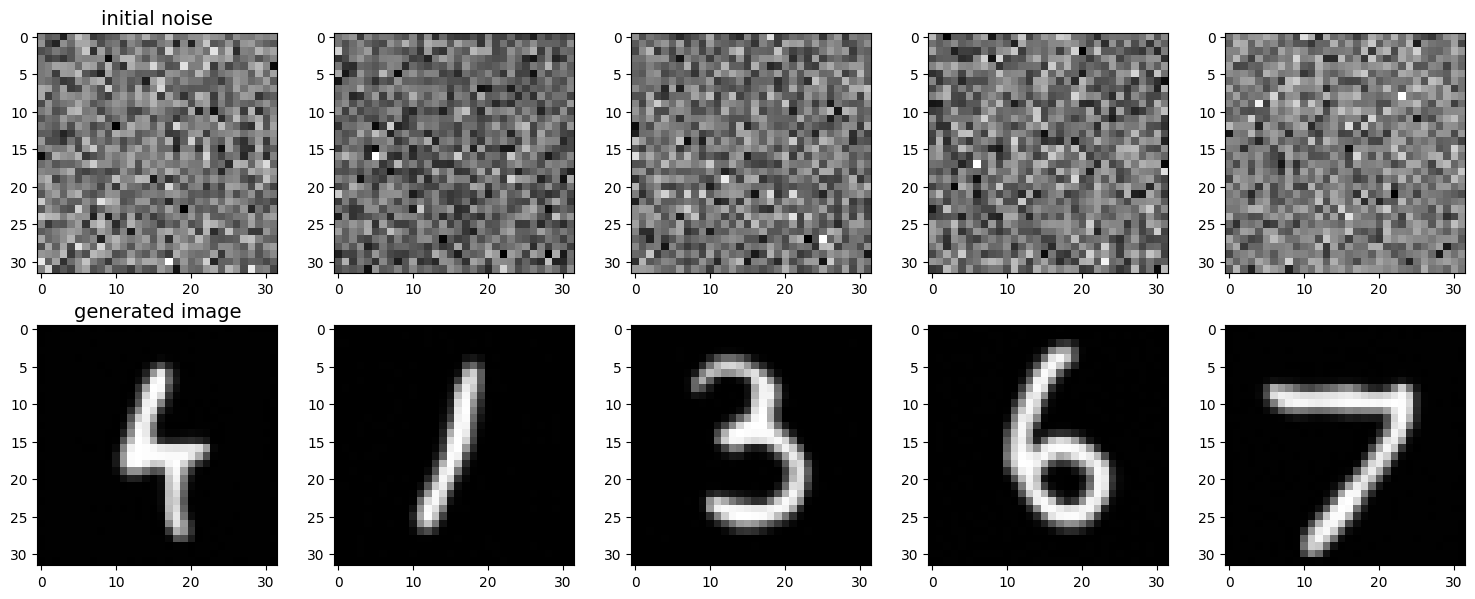

In [12]:
import importlib
from diffusion.utils import sample

importlib.reload(sample)

from diffusion.utils.sample import conditional_ddim_plot_samples


conditional_ddim_plot_samples(denoise_model, eta=0.0, interval=1, cond=scaled_metrics, w=0.1, image_size=32, batch_size=5, timesteps=500)

### 2025-07-17_18チェックポイント

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import itertools
from tqdm.auto import tqdm

from diffusion.utils.utils import load_json
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint
import json


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-17_16/config_20250717.json"
config = load_json(file_path)
epochs = config['epochs']
timesteps = config['timesteps']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename='/home/hashikami/checkpoint/checkpoint_2025-07-17_18.pth')

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 51.19it/s]


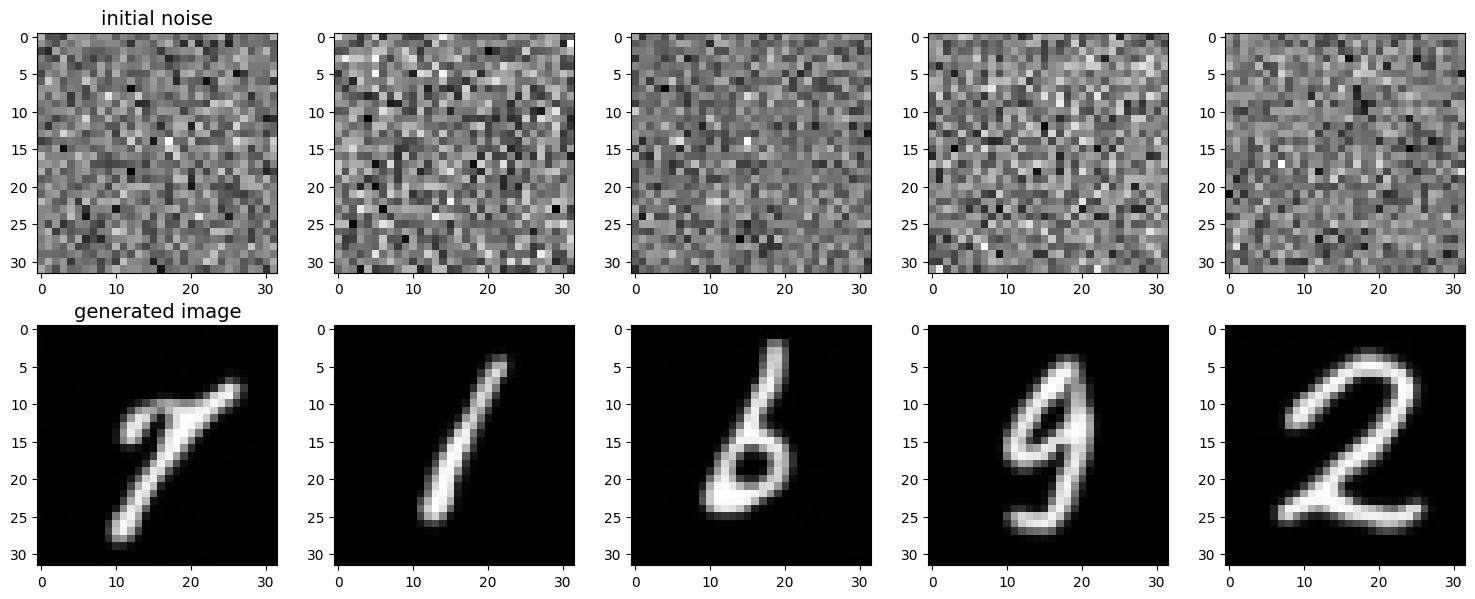

In [51]:
from diffusion.utils.sample import conditional_ddim_plot_samples

conditional_ddim_plot_samples(denoise_model, eta=0.0, interval=1, cond=metrics, w=0.1, image_size=32, batch_size=5, timesteps=500)

## 1.2 介入後条件付き画像編集

In [86]:
import torch

# "images.pt"として保存したテンソルを読み込む
loaded_images = torch.load("resources/image9_size28_scale255.pt")
loaded_metrics = torch.load("resources/metrics_image9.pt")

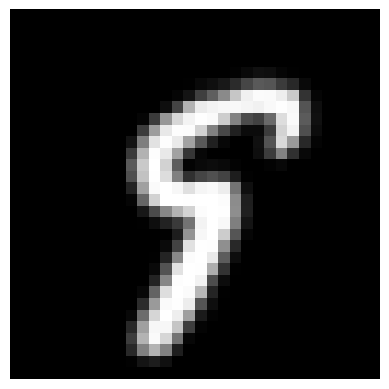

In [52]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 画像ファイルをPILで開く
img_pil = Image.open("resources/image9_size32_scale255.png").convert('L')  # グレースケール

# PIL画像をnumpy配列に変換
img_np = np.array(img_pil)

# numpy配列をtorchテンソルに変換（float32, 0-1正規化）
img_tensor = torch.from_numpy(img_np).float() #/ 255.0

# 可視化
plt.imshow(img_tensor.numpy(), cmap='gray')
plt.axis('off')
plt.show()


### 1.2.1 1枚の画像をガイダンススケール固定で様々な介入条件で編集

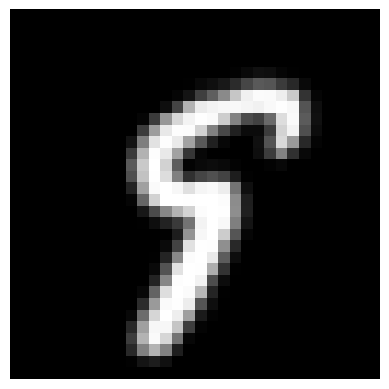

In [ ]:
plt.imshow(images[0].squeeze(), cmap='gray')
plt.axis('off')
plt.show()



In [6]:
def make_value_lists(t, a, b, num_steps=5):
    """
    (1,2)形状のtorch.tensor t から2つの値を取り出し、
    1つ目の値については正の値aで加算・減算を繰り返して等間隔のリストを作り、
    2つ目の値については正の値bで同様にリストを作る。

    Returns:
        intensity_values, thickness_values
    """
    first_value = t[0][0].item()
    second_value = t[0][1].item()
    intensity_values = [round(first_value - (num_steps//2 - i)*a, 4) for i in range(num_steps)]
    thickness_values = [round(second_value - (num_steps//2 - i)*b, 4) for i in range(num_steps)]
    return intensity_values, thickness_values

#### 2025-07-17_14チェックポイント

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import itertools
from tqdm.auto import tqdm

from diffusion.utils.utils import load_json
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint
import json

# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-17_13/config_20250717.json"
config = load_json(file_path)
epochs = config['epochs']
timesteps = config['timesteps']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)

denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename='/home/hashikami/checkpoint/checkpoint_2025-07-17_14.pth')

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


In [9]:
from diffusion.utils.preprocess import min_max_scale
from diffusion.utils.utils import load_json


cond_stats_path = "dataset/cond_stats.json"
cond_stats = load_json(cond_stats_path)

intensity_values, thickness_values = make_value_lists(metrics, 10, 0.5, num_steps=5)
scaled_intensity = [min_max_scale(sc_it, cond_stats['intensity']['min'], cond_stats['intensity']['max']) for sc_it in intensity_values]
scaled_thickness = [min_max_scale(sc_th, cond_stats['thickness']['min'], cond_stats['thickness']['max']) for sc_th in thickness_values]

In [13]:
from diffusion.utils.diffusion_utils import DiffusionUtils
import numpy as np

eta=0.0
interval=1
cond=metrics
w=0.5
batch_size=1
image_size=32
timesteps=500
input_img=images.unsqueeze(1).to(device)
utils = DiffusionUtils(timesteps=timesteps)

# 5×5のリスト
editted_images = [[] for _ in range(len(intensity_values))]
for i in range(len(scaled_intensity)):
    for j in range(len(scaled_thickness)):
        intervened_metrics = torch.Tensor([[scaled_intensity[i], scaled_thickness[j]]]).to(device)
        noises = utils.ddim_p_sample_loop(denoise_model, eta, interval, scaled_metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=True, input_img=input_img)
        imgs = utils.ddim_p_sample_loop(denoise_model, eta, interval, intervened_metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=False, noise=noises[-1])
        editted_images[i].append(imgs[-1].cpu().detach().numpy())

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 52.90it/s]


#### 2025-07-17_18チェックポイント

In [106]:
# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-17_16/config_20250717.json"
config = load_json(file_path)
epochs = config['epochs']
timesteps = config['timesteps']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename='/home/hashikami/checkpoint/checkpoint_2025-07-17_18.pth')

In [111]:
intensity_values, thickness_values = make_value_lists(metrics, 30.0, 1.5, num_steps=5)

In [112]:
from diffusion.utils.diffusion_utils import DiffusionUtils
import numpy as np

eta=0.0
interval=1
cond=metrics
w=0.1
batch_size=1
image_size=32
timesteps=500
input_img=images.unsqueeze(1).to(device)
utils = DiffusionUtils(timesteps=timesteps)

# 5×5のリスト
editted_images = [[] for _ in range(len(intensity_values))]
for i in range(len(intensity_values)):
    for j in range(len(thickness_values)):
        intervened_metrics = torch.Tensor([[intensity_values[i], thickness_values[j]]]).to(device)
        noises = utils.ddim_p_sample_loop(denoise_model, eta, interval, metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=True, input_img=input_img)
        imgs = utils.ddim_p_sample_loop(denoise_model, eta, interval, intervened_metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=False, noise=noises[-1])
        editted_images[i].append(imgs[-1].cpu().detach().numpy())

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 53.56it/s]


#### 画像のスケールを可視化

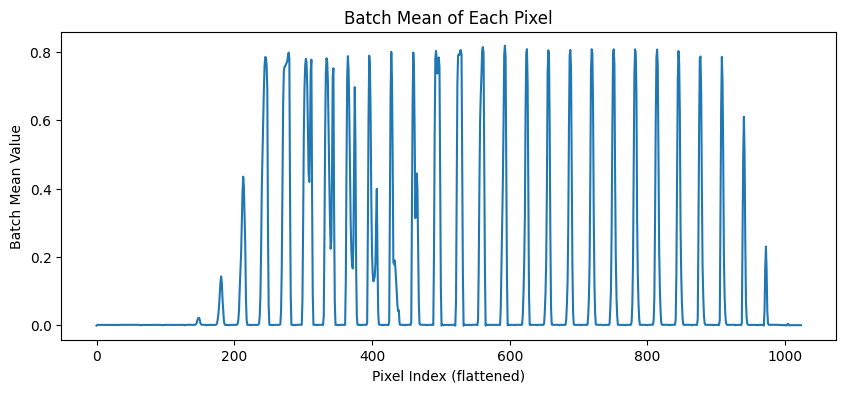

In [30]:
import matplotlib.pyplot as plt
import torch

def visualize_batch_pixel_mean(images):
    """
    (B, C, H, W)の画像テンソル（C=1）について、
    横軸：ピクセル位置（flattenしたインデックス or 0~H*W-1）
    縦軸：バッチ全体での各ピクセルの平均値
    """
    if isinstance(images, torch.Tensor):
        images_np = images.cpu().numpy()
    else:
        images_np = images
    # images_np: (B, 1, H, W)
    B, C, H, W = images_np.shape
    # flatten (B, 1, H, W) -> (B, H*W)
    images_flat = images_np.reshape(B, -1)
    # バッチ方向に平均
    mean_pixel = images_flat.mean(axis=0)  # shape: (H*W,)
    plt.figure(figsize=(10, 4))
    plt.plot(mean_pixel)
    plt.xlabel("Pixel Index (flattened)")
    plt.ylabel("Batch Mean Value")
    plt.title("Batch Mean of Each Pixel")
    plt.show()

# 例: editted_imagesの一部を可視化
# editted_imagesは2次元リストなので、例えばeditted_images[0][0]などをまとめて可視化
# ここでは全ての画像をまとめて可視化する例
all_imgs = []
for row in editted_images:
    for img in row:
        img = img.squeeze(0)
        all_imgs.append(img)
all_imgs = np.stack(all_imgs)  # shape: (N, 1, H, W)
visualize_batch_pixel_mean(torch.from_numpy(all_imgs))

#### 画像のスケールを0-1から0-255に変換

In [113]:
def scale_image_0_1_to_0_255(image):
    """
    画像の各ピクセル値を0~1スケールから0~255スケールに変換する関数

    Args:
        image (np.ndarray or torch.Tensor): 0~1スケールの画像

    Returns:
        np.ndarray or torch.Tensor: 0~255スケールの画像（同じ型で返す）
    """
    if isinstance(image, torch.Tensor):
        return (image * 255).clamp(0, 255).to(torch.uint8)
    else:
        return np.clip(image * 255, 0, 255).astype(np.uint8)

# edited_imagesの各要素（画像）を0~255スケールに変換
edited_images_255 = [
    [scale_image_0_1_to_0_255(img) for img in row]
    for row in editted_images
]

images_255 = scale_image_0_1_to_0_255(images)

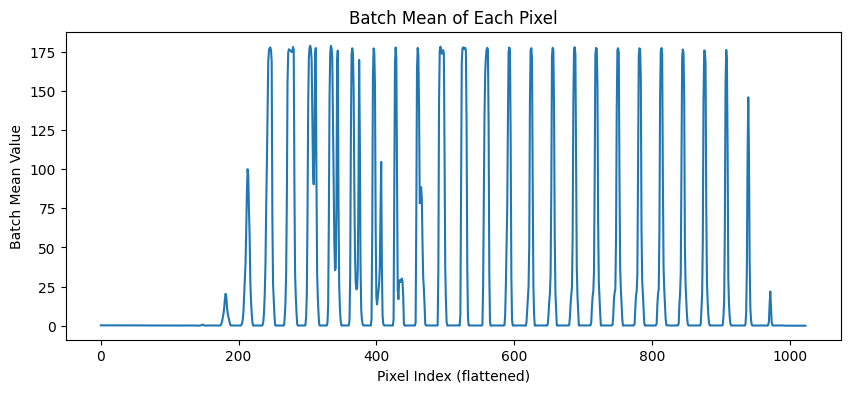

In [104]:

all_imgs_255 = []
for row in edited_images_255:
    for img in row:
        img = img.squeeze(0)
        all_imgs_255.append(img)
all_imgs_255 = np.stack(all_imgs_255)  # shape: (N, 1, H, W)
visualize_batch_pixel_mean(torch.from_numpy(all_imgs_255))

In [92]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_edit_grid(input_image, edited_images, brightness_values, thickness_values):
    """
    入力画像と編集済み画像のグリッドを可視化（各画像に明るさ・太さの値を表示）

    Args:
        input_image (ndarray): 入力画像（1枚）shape: [H, W] or [1, H, W]
        edited_images (2D list): 2次元リスト [thickness_i][brightness_j] の画像
        brightness_values (list): 横軸（明るさ）の値
        thickness_values (list): 縦軸（太さ）の値
    """
    n_thick = len(thickness_values)
    n_bright = len(brightness_values)
    fig, axes = plt.subplots(n_thick, n_bright, figsize=(2 * n_bright, 2.5 * n_thick))

    for i in range(n_bright):
        for j in range(n_thick):
            ax = axes[i, j]
            ax.axis('off')
            if i == n_bright // 2 and j == n_thick // 2:
                # 真ん中：入力画像
                ax.imshow(np.squeeze(input_image), cmap='gray')
                ax.set_title(f"Original, I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=8)
                ax.set_xlabel(f"I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=6)
            else:
                ax.imshow(np.squeeze(edited_images[i][j]), cmap='gray')
                ax.set_title(f"I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=6)

    # 下と左に補足
    fig.text(0.5, -0.05, '→ Thickness increases', ha='center', fontsize=10)
    fig.text(-0.05, 0.5, '← Intensity increases', va='center', rotation='vertical', fontsize=10)

    plt.tight_layout()
    plt.show()


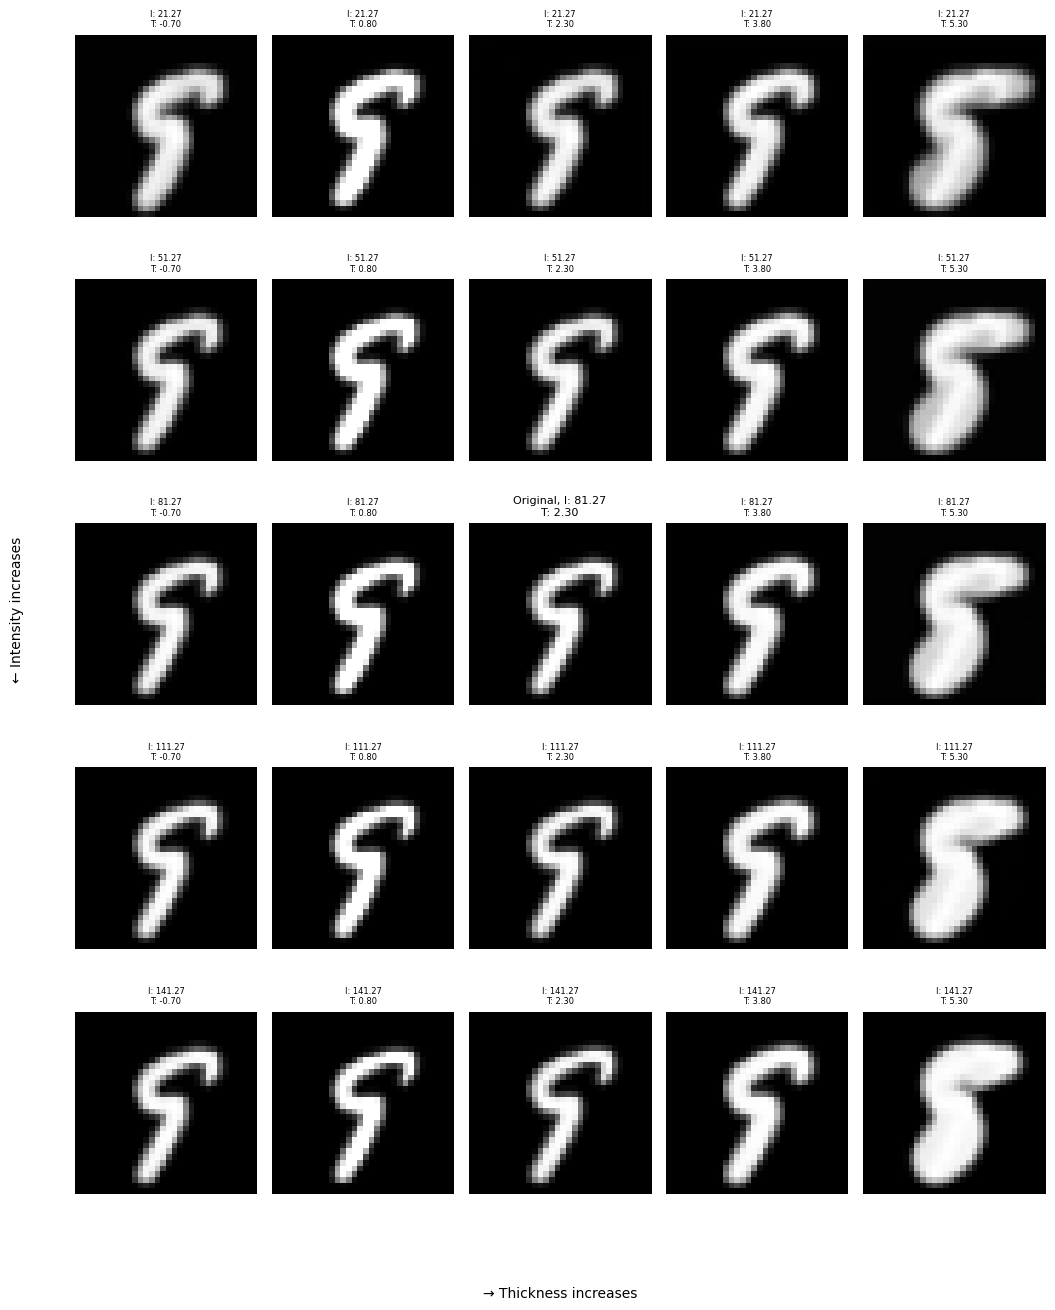

In [114]:
visualize_edit_grid(images_255, edited_images_255, intensity_values, thickness_values)